In [ ]:
import torch

print("PyTorch version:", torch.__version__)
print("GPU available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("No GPU available")

PyTorch version: 2.11.0+cu128
GPU available: True
GPU: Tesla T4


In [ ]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
import os

PROJECT_DIR = "/content/drive/MyDrive/cv_project"

DATASET_DIR = os.path.join(PROJECT_DIR, "dataset")
DATA_YAML = os.path.join(DATASET_DIR, "data.yaml")

OUTPUTS_DIR = os.path.join(PROJECT_DIR, "outputs")
TRAINING_DIR = os.path.join(OUTPUTS_DIR, "training_results")
PREDICTIONS_DIR = os.path.join(OUTPUTS_DIR, "predictions")
DEMO_DIR = os.path.join(OUTPUTS_DIR, "demo_results")

MODELS_DIR = os.path.join(PROJECT_DIR, "models")

print("Project:", PROJECT_DIR)
print("Dataset:", DATASET_DIR)
print("data.yaml:", DATA_YAML)

Project: /content/drive/MyDrive/cv_project
Dataset: /content/drive/MyDrive/cv_project/dataset
data.yaml: /content/drive/MyDrive/cv_project/dataset/data.yaml


In [ ]:
import os

paths_to_check = [
    PROJECT_DIR,
    DATASET_DIR,
    DATA_YAML,
    os.path.join(DATASET_DIR, "images", "train"),
    os.path.join(DATASET_DIR, "images", "val"),
    os.path.join(DATASET_DIR, "images", "test"),
    os.path.join(DATASET_DIR, "labels", "train"),
    os.path.join(DATASET_DIR, "labels", "val"),
    os.path.join(DATASET_DIR, "labels", "test"),
]

for path in paths_to_check:
    print(f"{'OK' if os.path.exists(path) else 'MISSING'}: {path}")

OK: /content/drive/MyDrive/cv_project
OK: /content/drive/MyDrive/cv_project/dataset
OK: /content/drive/MyDrive/cv_project/dataset/data.yaml
OK: /content/drive/MyDrive/cv_project/dataset/images/train
OK: /content/drive/MyDrive/cv_project/dataset/images/val
OK: /content/drive/MyDrive/cv_project/dataset/images/test
OK: /content/drive/MyDrive/cv_project/dataset/labels/train
OK: /content/drive/MyDrive/cv_project/dataset/labels/val
OK: /content/drive/MyDrive/cv_project/dataset/labels/test


In [ ]:
!pip install -U ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.6/46.6 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 24.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.7/77.7 kB 7.7 MB/s eta 0:00:00


In [ ]:
from ultralytics import YOLO

print("Ultralytics is ready.")

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
Ultralytics is ready.


In [ ]:
with open(DATA_YAML, "r") as f:
    print(f.read())

train: ../images/train
val: ../images/val
test: ../images/test

nc: 4
names: ['helmet', 'motorcycle_normal', 'motorcycle_overloaded', 'no_helmet']

roboflow:
  workspace: hassan-fc1yg
  project: motorcycle-violation-detection
  version: 1
  license: CC BY 4.0
  url: https://universe.roboflow.com/hassan-fc1yg/motorcycle-violation-detection/dataset/1


In [ ]:
from pathlib import Path

image_extensions = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

for split in ["train", "val", "test"]:
    folder = Path(DATASET_DIR) / "images" / split

    images = [
        f for f in folder.iterdir()
        if f.suffix.lower() in image_extensions
    ]

    print(f"{split}: {len(images)} images")

total = sum(
    len([
        f for f in (Path(DATASET_DIR) / "images" / split).iterdir()
        if f.suffix.lower() in image_extensions
    ])
    for split in ["train", "val", "test"]
)

print("Total:", total)

train: 405 images
val: 116 images
test: 57 images
Total: 578


In [ ]:
from pathlib import Path

for split in ["train", "val", "test"]:
    image_dir = Path(DATASET_DIR) / "images" / split
    label_dir = Path(DATASET_DIR) / "labels" / split

    images = {
        f.stem for f in image_dir.iterdir()
        if f.suffix.lower() in image_extensions
    }

    labels = {
        f.stem for f in label_dir.iterdir()
        if f.suffix.lower() == ".txt"
    }

    missing_labels = images - labels
    extra_labels = labels - images

    print(f"\n{split}")
    print("Images:", len(images))
    print("Labels:", len(labels))
    print("Missing labels:", len(missing_labels))
    print("Extra labels:", len(extra_labels))


train
Images: 405
Labels: 405
Missing labels: 0
Extra labels: 0

val
Images: 116
Labels: 116
Missing labels: 0
Extra labels: 0

test
Images: 57
Labels: 57
Missing labels: 0
Extra labels: 0


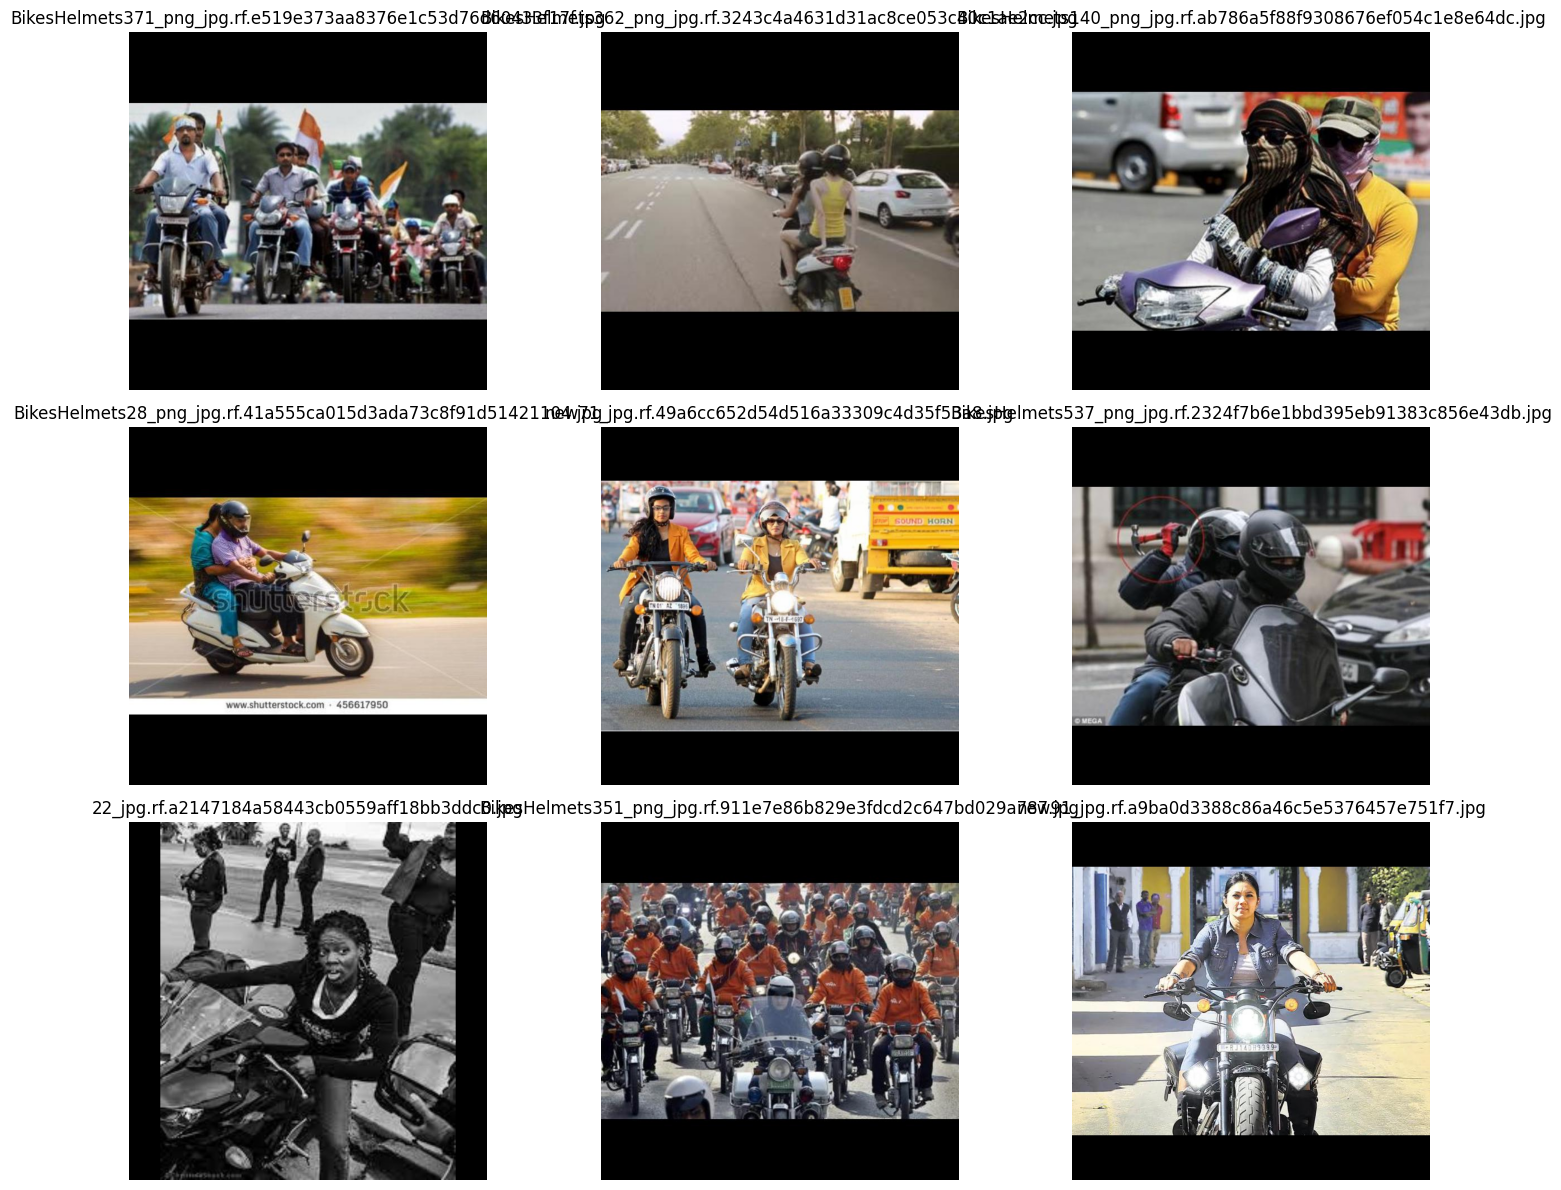

In [ ]:
import random
import matplotlib.pyplot as plt
from PIL import Image

train_dir = Path(DATASET_DIR) / "images" / "train"

image_files = [
    f for f in train_dir.iterdir()
    if f.suffix.lower() in image_extensions
]

sample_files = random.sample(
    image_files,
    min(9, len(image_files))
)

plt.figure(figsize=(15, 12))

for i, img_path in enumerate(sample_files):
    img = Image.open(img_path)

    plt.subplot(3, 3, i + 1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(img_path.name)

plt.tight_layout()
plt.show()

In [ ]:
import random
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image

# Training images
TRAIN_IMAGES_DIR = Path(DATASET_DIR) / "images" / "train"

image_files = [
    f for f in TRAIN_IMAGES_DIR.iterdir()
    if f.suffix.lower() in image_extensions
]

print("Number of training images:", len(image_files))


def show_yolo_image(image_path, label_path):
    image = Image.open(image_path).convert("RGB")
    width, height = image.size

    plt.figure(figsize=(12, 8))
    plt.imshow(image)

    # Check whether label exists
    if not label_path.exists():
        print("WARNING: Label file not found!")
        print("Expected label:", label_path)
    else:
        with open(label_path, "r") as f:
            lines = f.readlines()

        for line in lines:
            parts = line.strip().split()

            if len(parts) != 5:
                continue

            class_id = int(parts[0])
            x_center = float(parts[1]) * width
            y_center = float(parts[2]) * height
            box_width = float(parts[3]) * width
            box_height = float(parts[4]) * height

            x1 = x_center - box_width / 2
            y1 = y_center - box_height / 2

            rectangle = plt.Rectangle(
                (x1, y1),
                box_width,
                box_height,
                fill=False,
                linewidth=2
            )

            plt.gca().add_patch(rectangle)

            if 0 <= class_id < len(class_names):
                class_name = class_names[class_id]
            else:
                class_name = f"UNKNOWN CLASS {class_id}"

            plt.text(
                x1,
                y1,
                class_name,
                fontsize=10,
                backgroundcolor="white"
            )

    # Show filename prominently
    plt.title(
        f"Filename: {image_path.name}",
        fontsize=14
    )

    plt.axis("off")
    plt.show()

    # Print exact locations
    print("IMAGE:")
    print(image_path)

    print("\nLABEL:")
    print(label_path)

Number of training images: 405


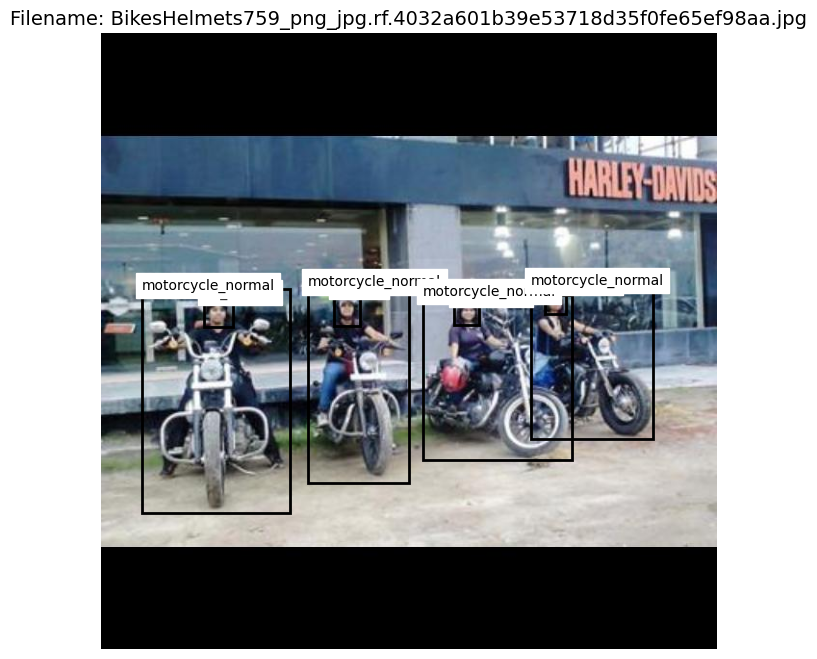

IMAGE:
/content/drive/MyDrive/cv_project/dataset/images/train/BikesHelmets759_png_jpg.rf.4032a601b39e53718d35f0fe65ef98aa.jpg

LABEL:
/content/drive/MyDrive/cv_project/dataset/labels/train/BikesHelmets759_png_jpg.rf.4032a601b39e53718d35f0fe65ef98aa.txt


In [ ]:
image_path = random.choice(image_files)

label_path = (
    Path(DATASET_DIR)
    / "labels"
    / "train"
    / f"{image_path.stem}.txt"
)

show_yolo_image(image_path, label_path)

In [ ]:
model = YOLO("yolov8n.pt")

In [ ]:
results = model.train(
    data=DATA_YAML,
    epochs=30,
    imgsz=640,
    batch=8,
    pretrained=True,
    project=TRAINING_DIR,
    name="baseline"
)

Ultralytics 8.4.153 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/cv_project/dataset/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=baseline, nbs=64, nms=None

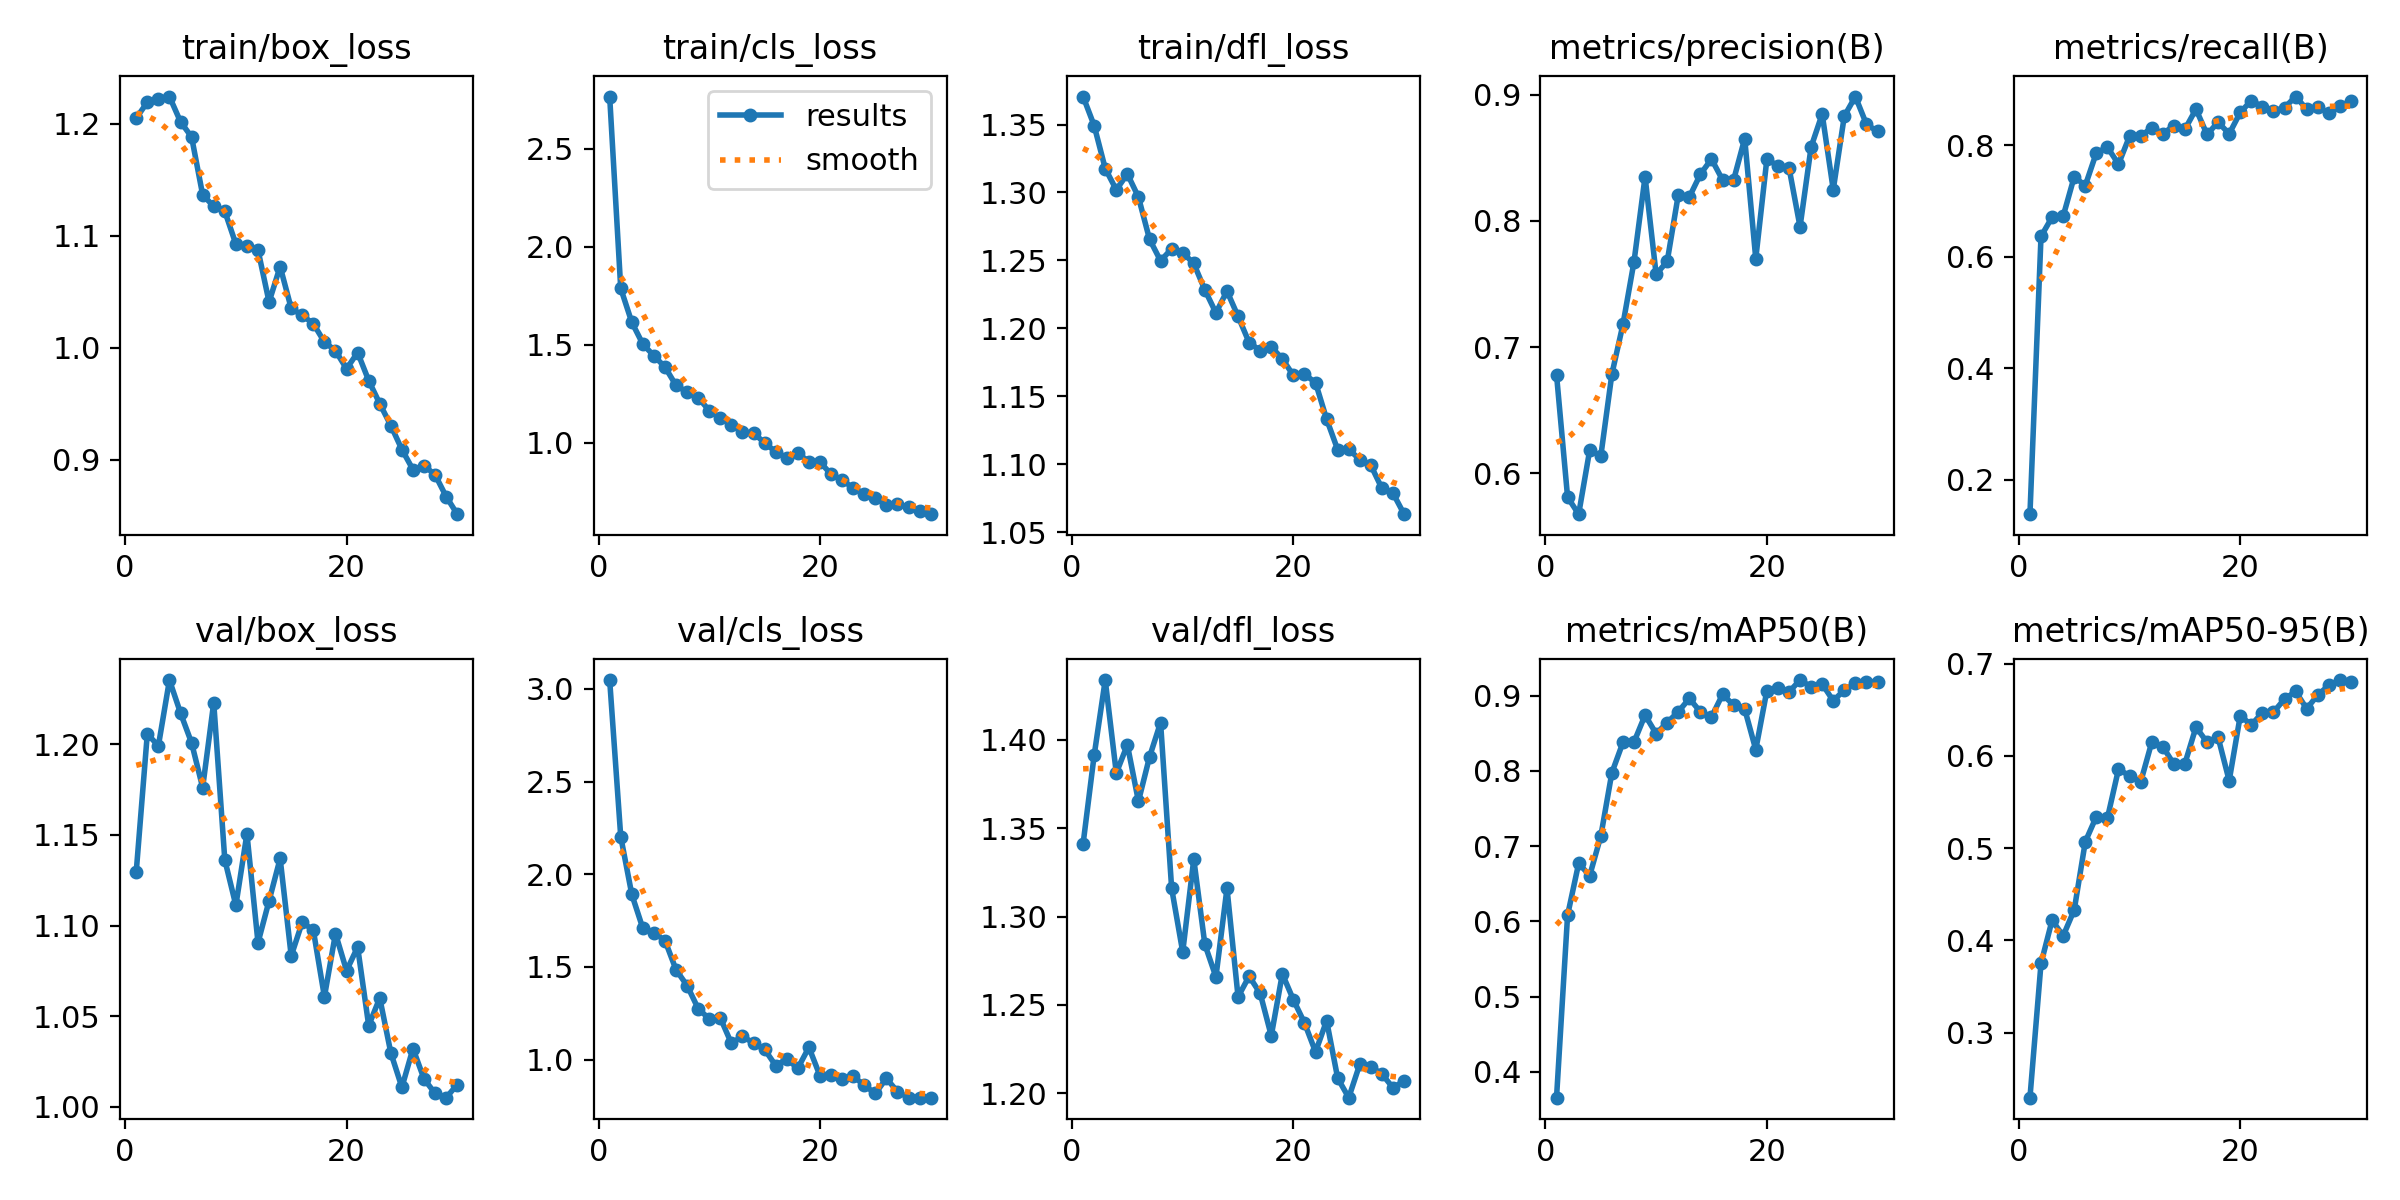

In [ ]:
from IPython.display import Image, display

results_plot = os.path.join(
    TRAINING_DIR,
    "baseline",
    "results.png"
)

display(Image(filename=results_plot))

In [ ]:
import os
train_img = "/content/drive/MyDrive/cv_project/dataset/images/train"
print("Training images:", len(os.listdir(train_img)))

Training images: 405


In [ ]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

results = model.train(
    data=DATA_YAML,
    epochs=75,
    imgsz=640,
    batch=8,
    pretrained=True,
    cls=1.5,
    project=TRAINING_DIR,
    name="yolov8n_75epochs"
)

Ultralytics 8.4.153 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=1.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/cv_project/dataset/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=75, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8n_75epochs, nbs=64, 

In [ ]:
model = YOLO("yolov8s.pt")

results = model.train(
    data=DATA_YAML,
    epochs=75,
    imgsz=640,
    batch=8,
    pretrained=True,
    cls=1.5,
    project=TRAINING_DIR,
    name="yolov8s_75epochs"
)

Ultralytics 8.4.153 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=1.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/cv_project/dataset/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=75, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8s_75epochs, nbs=64, 

In [ ]:
model = YOLO("yolov8n.pt")
results = model.train(
    data=DATA_YAML,
    epochs=75,
    imgsz=640,
    batch=16,
    pretrained=True,
    project=TRAINING_DIR,
    name="YOLOv8n_75epochs_16Batch"
)

Ultralytics 8.4.153 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/cv_project/dataset/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=75, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=YOLOv8n_75epochs_16Batch,

In [ ]:
model = YOLO("yolov8n.pt")
results = model.train(
    data=DATA_YAML,
    epochs=40,
    imgsz=640,
    batch=16,
    pretrained=True,
    project=TRAINING_DIR,
    name="YOLOv8n_40epochs_16Batch"
)

Ultralytics 8.4.153 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/cv_project/dataset/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=40, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=YOLOv8n_40epochs_16Batch,

In [ ]:
model = YOLO("yolov8n.pt")
results = model.train(
    data=DATA_YAML,
    epochs=40,
    imgsz=640,
    batch=8,
    pretrained=True,
    project=TRAINING_DIR,
    name="YOLOv8n_40epochs_8Batch"
)

Ultralytics 8.4.153 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/cv_project/dataset/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=40, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=YOLOv8n_40epochs_8Batch, n

In [1]:
import shutil
shutil.copy(
    "/content/drive/MyDrive/cv_project/outputs/training_results/YOLOv8n_40epochs_16Batch/weights/best.pt",
    "/content/drive/MyDrive/cv_project/models/best.pt"
)
print("Final model saved")

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/cv_project/outputs/training_results/YOLOv8n_40epochs_16Batch/weights/best.pt'

In [ ]:
print(model.names)

{0: 'helmet', 1: 'motorcycle_normal', 2: 'motorcycle_overloaded', 3: 'no_helmet'}


In [ ]:
import cv2
import os
from ultralytics import YOLO

model = YOLO("/content/drive/MyDrive/cv_project/models/best.pt")

results = model.predict(
    source="/content/drive/MyDrive/cv_project/dataset/images/test",
    conf=0.25,
    iou=0.4,
    agnostic_nms=True,
    save=False
)

class_names = ['helmet', 'motorcycle_normal', 'motorcycle_overloaded', 'no_helmet']
colors = {
    'helmet': (255, 165, 0),
    'motorcycle_normal': (0, 255, 0),
    'motorcycle_overloaded': (0, 0, 255),
    'no_helmet': (255, 0, 255)
}

output_dir = "/content/drive/MyDrive/cv_project/outputs/predictions/final/"
os.makedirs(output_dir, exist_ok=True)

for r in results:
    img = r.orig_img.copy()

    if r.boxes is not None:
        for box in r.boxes:
            cls_id = int(box.cls[0])
            conf = float(box.conf[0])
            name = class_names[cls_id]
            color = colors[name]

            x1, y1, x2, y2 = map(int, box.xyxy[0])
            cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)

            label = f"{name} {conf:.2f}"
            font = cv2.FONT_HERSHEY_SIMPLEX
            (tw, th), _ = cv2.getTextSize(label, font, 0.45, 1)
            label_y = y1 - 5 if y1 - 5 > th else y2 + th + 5
            cv2.rectangle(img, (x1, label_y - th - 2), (x1 + tw, label_y + 2), color, -1)
            cv2.putText(img, label, (x1, label_y), font, 0.45, (255, 255, 255), 1)

    fname = os.path.basename(r.path)
    cv2.imwrite(os.path.join(output_dir, fname), img)

print(f"Done. Saved to {output_dir}")
print(f"Total: {len(results)} images")


image 1/57 /content/drive/MyDrive/cv_project/dataset/images/test/1-1-_jpeg_jpg.rf.2243387a92f87f70adc08faf141fde4a.jpg: 640x640 2 helmets, 3 motorcycle_normals, 5 no_helmets, 7.2ms
image 2/57 /content/drive/MyDrive/cv_project/dataset/images/test/1-13-_jpeg_jpg.rf.5fb891ffdc14fd41a9e2f4b00112fe1f.jpg: 640x640 1 helmet, 1 motorcycle_normal, 1 no_helmet, 9.5ms
image 3/57 /content/drive/MyDrive/cv_project/dataset/images/test/1-18-_png_jpg.rf.8798c37269ff4d3856b443db81b8cf92.jpg: 640x640 1 motorcycle_normal, 2 no_helmets, 7.2ms
image 4/57 /content/drive/MyDrive/cv_project/dataset/images/test/1-32-_jpg.rf.32005502eeb1d9861eb4b1f7ad53bafe.jpg: 640x640 1 motorcycle_normal, 1 motorcycle_overloaded, 6 no_helmets, 9.2ms
image 5/57 /content/drive/MyDrive/cv_project/dataset/images/test/1-4-_jpeg_jpg.rf.89482a425655ddc4d5f8d4edb6dd5b44.jpg: 640x640 2 helmets, 2 motorcycle_normals, 5 no_helmets, 8.6ms
image 6/57 /content/drive/MyDrive/cv_project/dataset/images/test/1-49-_jpg.rf.212f31f3af7216905e85a